# Malaria Classification Task (Infected or UnInfected)

## Dataset Description

In [ ]:
# Colored Picture usually have 3 channels - Red, Blue and Green. Each pixel is made of a combination of these 3 channels. 
# So our tensor for a colored picture will be (H,W,3): 3 is for 3 channels. A gray scale image has only 1 channel, therefore we have (H,W,1)
# (Black = 0) --- (White = 255)
# After Normalization, (Black = 0) --- (White = 1)

## Importing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # type: ignore
import tensorflow_datasets as tfds # type: ignore
import tensorflow_probability as tfp # type: ignore
import sklearn 
from sklearn.metrics import confusion_matrix, roc_curve
import seaborn as sns
import cv2

# MODELS
Model = tf.keras.Model

#LAYERS
Layer = tf.keras.layers.Layer # importing Layer Class to inherit from
Input = tf.keras.layers.Input
Normalization = tf.keras.layers.Normalization
Dense = tf.keras.layers.Dense
InputLayer = tf.keras.layers.InputLayer
Conv2D = tf.keras.layers.Conv2D
MaxPool2D = tf.keras.layers.MaxPool2D
Flatten = tf.keras.layers.Flatten # Flatten is a function so you don't need a parantheses at the end.
BatchNormalization = tf.keras.layers.BatchNormalization
Dropout =  tf.keras.layers.Dropout
RandomRotation = tf.keras.layers.RandomRotation
RandomFlip = tf.keras.layers.RandomFlip
Resizing = tf.keras.layers.Resizing
Rescaling = tf.keras.layers.Rescaling

#LOSSES
bce = tf.keras.losses.BinaryCrossentropy() # To instantiate a class you need to build an object which can only be done by including a parantheses at the end. 

# OPTIMIZER
Adam = tf.keras.optimizers.Adam

# METRICS
BinaryAccuracy = tf.keras.metrics.BinaryAccuracy # For a Binary Classification Problem
FalsePositives = tf.keras.metrics.FalsePositives
FalseNegatives = tf.keras.metrics.FalseNegatives
TruePositives = tf.keras.metrics.TruePositives
TrueNegatives = tf.keras.metrics.TrueNegatives
Precision = tf.keras.metrics.Precision
Recall = tf.keras.metrics.Recall
AUC = tf.keras.metrics.AUC

# Callbacks
Callback = tf.keras.callbacks.Callback
CSVLogger = tf.keras.callbacks.CSVLogger
LearningRateScheduler = tf.keras.callbacks.LearningRateScheduler
ProgBarLogger = tf.keras.callbacks.ProgbarLogger
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint
ReduceLRonPlateau = tf.keras.callbacks.ReduceLROnPlateau

# Regularizer
L2 = tf.keras.regularizers.L2

# Distributions
Beta = tfp.distributions.Beta

## Loading the Dataset

In [2]:
dataset, dataset_info = tfds.load('malaria', with_info=True, as_supervised = True, shuffle_files=True, split=['train']) # tfds_load returns the dataset and dataset_info | 'with_info=True' gives the dataset_info
# as_supervised -> if True returns a dataset with a 2 tuple structure (input, label)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.DJDO11_1.0.0/malaria-train.tfrecord-[0-9][0-9][0-9][0-9…

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [3]:
dataset # this is a list with 1 element, so only select dataset[0]
# dataset_info
# for data in dataset[0].take(2):
#     print(data)

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

### Creating the Train, Test, Validation Datasets

In [4]:
def splits(dataset, TRAIN_RATIO, VAL_RATIO, TEST_RATIO):
    DATASET_SIZE = len(dataset)

    # 1. Take the first 60% for training
    train_dataset = dataset.take(int(TRAIN_RATIO * DATASET_SIZE)) 

    # 2. Skip that 60% to look at the remaining 40% pool
    remaining_dataset = dataset.skip(int(TRAIN_RATIO * DATASET_SIZE))

    # 3. Take the first 20% of the total size from the remaining pool
    val_dataset = remaining_dataset.take(int(VAL_RATIO * DATASET_SIZE)) 

    # 4. Skip past the validation data to get the 5% and leave out 15% of the data
    test_pool = remaining_dataset.skip(int(TEST_RATIO * DATASET_SIZE))
    test_dataset = test_pool.take(int(TEST_RATIO * DATASET_SIZE))

    return train_dataset, val_dataset, test_dataset



In [5]:
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.05
# dataset = tf.data.Dataset.range(10)
train_dataset, val_dataset, test_dataset = splits(dataset[0], TRAIN_RATIO, VAL_RATIO, TEST_RATIO)
# print('Train Dataset\n', list(train_dataset.take(1).as_numpy_iterator()),'Val Dataset\n', list(val_dataset.take(1).as_numpy_iterator()),'Test Dataset\n', list(test_dataset.take(1).as_numpy_iterator()))

In [165]:
# for image, label in train_dataset.take(16):
#     print("Image Matrix Shape:", image.shape) 
#     print("Label Value:", label.numpy())

# Data Visualization

In [166]:
# for i, (image, label) in enumerate(train_dataset.take(16)): # when using .take(), it goes from 1 - 16, hence the 'i+1'
#     ax = plt.subplot(4,4, i+1) #(4,4) because we have 16 images
#     plt.imshow(image)
#     plt.title(dataset_info.features['label'].int2str(label))
#     plt.axis('off')

In [167]:
# dataset_info.features['label'].int2str(0) # our label of 0 means that it is parasitized

In [168]:
# dataset_info.features['label'].int2str(1) # our label of 1 means that it is uninfected

# Data PreProcessing


## Standardization / Normalization and Resizing

In [6]:
IM_SIZE = 224
# Image Resizing: Converting each image to 224,224 resolution
def resize_rescale(image, label):
    return tf.image.resize(image,(IM_SIZE, IM_SIZE))/255.0, label
# We are dividing by 255 to rescale

In [7]:
# Augment via tf.keras.layers resizing and rescaling
resize_rescale_layers = tf.keras.Sequential([
    Resizing(IM_SIZE, IM_SIZE), # [0.25 * 360, 0.2501 * 360], to keep the rotation to 90 degrees
    Rescaling(1.0/255),
])

## Data Augmentation

In [8]:
def visualize(original, augmented):
    plt.subplot(1,2,1) ## Make a 1 row and 2 column plot and select the 1st position
    plt.imshow(original)

    plt.subplot(1,2,2)
    plt.imshow(augmented)

In [172]:
# original_image, label = next(iter(train_dataset))
# augmented_image = tf.image.random_saturation(original_image, lower = 2, upper = 10)
# visualize(original_image, augmented_image)

In [173]:
# augmented_image = tf.image.central_crop(original_image, central_fraction = 0.8) # we get the central part
# visualize(original_image, augmented_image)

In [174]:
# Why to not use saturation for this dataset
# for i, (image, label) in enumerate(test_dataset.take(2)):
#     plt.subplot(1,4,2*i+1)
#     plt.imshow(image)

#     plt.subplot(1,4,2*i+2)
#     plt.imshow(tf.image.adjust_saturation(image, 0.8))
#     plt.title(dataset_info.features['label'].int2str(label))
#     plt.axis('off')


In [8]:
# Augment via tf.image
# This method randomly picks which augmentation to do
def augment(image, label):

    image, label = resize_rescale(image, label)
    image = tf.image.rot90(image, k = tf.random.uniform(shape=[], minval=0, maxval=2, dtype=tf.int32))
    # image = tf.image.adjust_saturation(image, saturation_factor=0.3)
    # image = tf.image.stateless_random_saturation(image, 0.3, 0.5) 
    # # No point of adjusting contrast/saturation in our 
    # dataset becasue it makes it harder to differentiate between parasatized and non-parasatized cells
    image = tf.image.statless_random_flip_left_right(image)

    return image, label

In [176]:
# for image, label in train_dataset.take(1):
#     print(image, label)
# # Image is resized

In [9]:
class Rot90(Layer):
    def __init__(self):
        super().__init__()
    
    def call(self, image):
        return tf.image.rot90(image, k = tf.random.uniform(shape=[], minval=0, maxval=2, dtype=tf.int32))

In [10]:
# Augment via tf.keras.layers
augment_layers = tf.keras.Sequential([
    Rot90(), # [0.25 * 360, 0.2501 * 360], to keep the rotation to 90 degrees
    RandomFlip(mode='horiontal',)
])
def augment_layer(image, label):
    image, label = resize_rescale(image, label)
    return augment_layers(image, training = True), label

## Mixup Data Augmentation

### Mixup Data Augmentation Demonstration

In [ ]:
lamda = tfp.distributions.Beta(0.2,0.2)
lamda = lamda.sample(1)[0]

r_x = tf.cast(tfp.distributions.Uniform(low=0 , high=IM_SIZE).sample(1)[0], dtype = tf.int32)
r_y = tf.cast(tfp.distributions.Uniform(low=0 , high=IM_SIZE).sample(1)[0], dtype = tf.int32)


r_w = tf.cast(IM_SIZE * tf.math.sqrt(1-lamda), dtype = tf.int32)
r_h = tf.cast(IM_SIZE * tf.math.sqrt(1-lamda), dtype= tf.int32)

r_y = tf.clip_by_value(r_x - r_w//2, 0, IM_SIZE)
r_y = tf.clip_by_value(r_y - r_h//2, 0, IM_SIZE)

print(r_x, r_y, r_w, r_h)


tf.Tensor(218, shape=(), dtype=int32) tf.Tensor(56, shape=(), dtype=int32)


(224, 224, 3)
(224, 224, 3)
tf.Tensor(0.2293376, shape=(), dtype=float32)
(224, 224, 3) tf.Tensor(0.7706624, shape=(), dtype=float32)


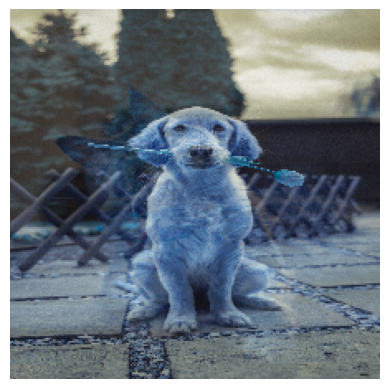

In [10]:
lamda = tfp.distributions.Beta(0.2,0.2)
lamda = lamda.sample(1)[0]

image_1 = cv2.resize(cv2.imread('cat.jpg'), (IM_SIZE, IM_SIZE)) # Upload pictures to Colab GPU to run this
image_2 = cv2.resize(cv2.imread('dog.jpg'), (IM_SIZE, IM_SIZE))

# image_1, label_1 = resize_rescale(cv2.imread('cat.jpg'), label=0)
# image_2, label_2 = resize_rescale(cv2.imread('dog.jpg'), label=1)

label_1 = 0
label_2 = 1

image = lamda * image_1 + (1-lamda) * image_2
label = lamda * tf.cast(label_1, dtype = tf.float32) + (1-lamda) * tf.cast(label_2, dtype = tf.float32)
print(image_1.shape)
print(image_2.shape)
print(lamda)
print(image_1.shape, label)
plt.axis('off')
plt.imshow(image/255,) # IMPORTANT to NORMALIZE it. Divide by 255

In [11]:
train_dataset_1 = train_dataset.shuffle(buffer_size = 8, reshuffle_each_iteration=True).map(resize_rescale)
train_dataset_2 = train_dataset.shuffle(buffer_size = 8, reshuffle_each_iteration=True).map(resize_rescale)

mixed_dataset = tf.data.Dataset.zip(train_dataset_1, train_dataset_2)

In [ ]:
def mixup(train_dataset_1, train_dataset_2):
    (image_1, label_1), (image_2, label_2) = train_dataset_1, train_dataset_2
    
    # image_1 = cv2.resize(cv2.imread('cat.jpg'), (IM_SIZE, IM_SIZE)) # Upload pictures to Colab GPU to run this
    # image_2 = cv2.resize(cv2.imread('dog.jpg'), (IM_SIZE, IM_SIZE))

    lamda = tfp.distributions.Beta(0.2,0.2)
    lamda = lamda.sample(1)[0]
    # print(lamda.sample(1)[0].numpy()) # but we will work with tensors so no need to include .numpy()

    label_1 = 0
    label_2 = 1

    image = lamda * image_1 + (1-lamda) * image_2
    label = lamda * tf.cast(label_1, dtype = tf.float32) + (1-lamda) * tf.cast(label_2, dtype = tf.float32)
    return image, label


# Can do this way as well
# image_1, label = resize_rescale(image_1, label=0)
# image_2, label = resize_rescale(image_2, label=1)
# print(image_1.shape)
# print(image_2.shape)
# print(lamda)
# print(image.shape, label)
# plt.imshow(image/255) # IMPORTANT to NORMALIZE it. Divide by 255
def mixupTWO(train_dataset_1, train_dataset_2):
    (image_1, label_1), (image_2, label_2) = train_dataset_1, train_dataset_2
    
    crop_2 = tf.image.crop_to_bounding_box(image_2 , 20, 60, 100, 98)
    pad_2 = tf.image.pad_to_bounding_box(crop_2, 20, 100, IM_SIZE, IM_SIZE)

    crop_1 = tf.image.crop_to_bounding_box(image_1, 20, 100, 100, 98)
    pad_1 = tf.image.pad_to_bounding_box(crop_1, 20, 100, IM_SIZE, IM_SIZE)

    image = image_1 - pad_1 + pad_2
    
    return image, label


## Cutmix Augmentation

### Cutmix Augmentation Demonstration

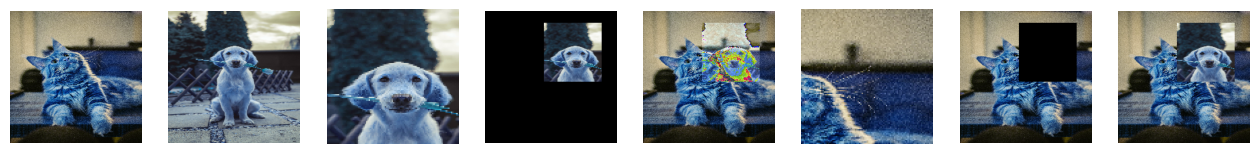

In [14]:
plt.figure(figsize=(16,8))

plt.subplot(1,8,1)
image_1 = cv2.resize(cv2.imread('cat.jpg'), (IM_SIZE, IM_SIZE))
plt.axis('off')
plt.imshow(image_1)

plt.subplot(1,8,2)
image_2 = cv2.resize(cv2.imread('dog.jpg'), (IM_SIZE, IM_SIZE))
plt.axis('off')
plt.imshow(image_2)


# Chopped Image Haha
plt.subplot(1,8,3)
crop = tf.image.crop_to_bounding_box(image_2 , 20, 60, 100, 98) # Zoomed In
plt.axis('off')
plt.imshow(crop)

# Image is stamped on a picture of 0's
plt.subplot(1,8,4)
padded = tf.image.pad_to_bounding_box(crop, 20, 100, IM_SIZE, IM_SIZE)
plt.axis('off')
plt.imshow(padded)

# Don't want this
plt.subplot(1,8,5)
plt.axis('off')
plt.imshow(padded + image_1)

plt.subplot(1,8,6)
crop_cat = tf.image.crop_to_bounding_box(image_1, 20, 100, 100, 98)
plt.axis('off')
plt.imshow(crop_cat)

plt.subplot(1,8,7)
image_5 = tf.image.pad_to_bounding_box(crop_cat, 20, 100, IM_SIZE, IM_SIZE)
plt.axis('off')
plt.imshow(image_1 - image_5)

# Add image to the HOLE
plt.subplot(1,8,8)
plt.axis('off')
plt.imshow(image_1 - image_5 + padded)


## Shuffling the dataset

In [20]:
BATCH_SIZE = 32
train_dataset = (mixed_dataset
                .shuffle(buffer_size=8, reshuffle_each_iteration=True)
                .map(mixup) # include the mapping AFTER shuffling
                .batch(BATCH_SIZE)
               #  .prefetch(tf.data.AUTOTUNE)
                )

# Don't reshuffle val_dataset, so no 'reshuffle_each_iteration=True', don't augment the val and test dataset
val_dataset = (val_dataset
               # .shuffle(buffer_size=8)
               .map(resize_rescale)
               .batch(BATCH_SIZE)
               # .prefetch(tf.data.AUTOTUNE)
               )

# Don't do anything with the test_dataset
test_dataset = test_dataset.map(resize_rescale)

In [21]:
print(train_dataset,'\n', val_dataset)
print(f'Length of training Dataset: {len(train_dataset) * 32}')
print(f'Length of Validation Dataset: {len(val_dataset) * 32}')
print(f'Length of Test Dataset: {len(test_dataset)}')

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))> 
 <_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
Length of training Dataset: 16544
Length of Validation Dataset: 5536
Length of Test Dataset: 1377


# Model Creation

### Sequential API

In [27]:
# LeNet Architecture
# The Models weights, are the filters that we learn
dropout_rate = 0.3
regularization_rate = 0.01
lenet_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                            
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu', kernel_regularizer=L2(regularization_rate)),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),
                            Dropout(rate=dropout_rate),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu',kernel_regularizer=L2(regularization_rate)),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            Dense(100, activation='relu', kernel_regularizer=L2(regularization_rate)),
                            BatchNormalization(),
                            Dropout(rate=dropout_rate),

                            Dense(10, activation='relu', kernel_regularizer=L2(regularization_rate)),
                            BatchNormalization(),

                            Dense(1, activation='sigmoid')
                            ])
lenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

## Functional API

In [18]:
# PUTTING ALL THE FEATURE EXTRACTOR LAYER INTO 'feature_extractor_model'
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '1st Convolution Layer')(func_input)
x = BatchNormalization(name = '1st Normalization Layer')(x) 
x = MaxPool2D(pool_size= 2, strides=2, name = '1st Pooling Layer')(x)
x = Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu', name = '2nd Convolution Layer')(x)
x = BatchNormalization(name = '2nd Normalization Layer')(x)

output = MaxPool2D(pool_size= 2, strides=2, name = 'output')(x)

feature_extractor_model = Model(func_input, output, name = 'Feature_Extractor')
feature_extractor_model.summary()

Model: "Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Convolution Layer (Conv2D)  │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Normalization Layer         │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st Pooling Layer               │ (None, 111, 111, 6)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Convolution Layer (Conv2D)  │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Normalization Layer         │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (MaxPooling2D)           │ (None, 54, 54, 16)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,136 (4.44 KB)

 Trainable params: 1,092 (4.27 KB)

 Non-trainable params: 44 (176.00 B)

## Adding the Feature Extractor Model to the Classification Layers

In [19]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_extractor_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)


# Need to mention that 'lenet_model_func' is a MODEL with 'func_input' and 'func_output'
lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()


Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Feature_Extractor (Functional)  │ (None, 54, 54, 16)     │         1,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

## Feature Extractor - Sequential Model

In [20]:
feature_extractor_seq_model = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2)])

x = feature_extractor_seq_model(func_input)


# Classification Layers
x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model')
lenet_model_func.summary()

Model: "Lenet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 54, 54, 16)     │         1,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

In [21]:
# tf.keras.utils.plot_model(lenet_model, to_file='model.png', show_shapes=True)

## Model SubClassing

In [22]:
class FeatureExtractor(Layer): # FeatureExtractor inherits from Layer
    def __init__(self, filters, kernel_size, strides, padding, activation, pool_size):
        super(FeatureExtractor, self).__init__() # This line reaches up to the parent Keras Layer class and boots up its internal initialization configuration.
        '''A native Keras layer has a ton of invisible, complex machinery required to track weight gradients and shape states.
           If you omit this line, your custom layer's setup will overwrite the core Keras setup, completely breaking the layer. Running super().__init__()
           ensures that Keras sets up its vital internal plumbing before you start adding your custom layers underneath it.'''
        


        # All the layers are being DEFINED here
        
        self.conv_1 = Conv2D(filters = filters, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        # we are equating filters = filters because we don't want to mix up the argument values here and how it is defined in the documentation
        self.batch_1 = BatchNormalization()
        self.pool_1 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)

        self.conv_2 = Conv2D(filters = filters * 2, kernel_size = kernel_size, strides = strides, padding = padding, activation = activation)
        self.batch_2 = BatchNormalization()
        self.pool_2 = MaxPool2D(pool_size = pool_size, strides = 2 * strides)


    def call(self, x, training = False): 
        x = self.conv_1(x)
        x = self.batch_1(x)
        x = self.pool_1(x)

        x = self.conv_2(x)
        x = self.batch_2(x)
        x = self.pool_2(x)

        return x
        

feature_sub_classed = FeatureExtractor(8, 3, 1, 'valid', 'relu', 2)

In [23]:
func_input = Input(shape = (IM_SIZE, IM_SIZE,3), name = 'Input Image')

x = feature_sub_classed(func_input) 
# When you pass func_input into feature_sub_classed(...), 
# Keras automatically jumps inside your custom class and runs the 'call' method under the hood.

x = Flatten()(x) 

x = Dense(100, activation='relu')(x)
x = BatchNormalization()(x)

x = Dense(10, activation='relu')(x)
x = BatchNormalization()(x)

func_output = Dense(1, activation='sigmoid')(x)

lenet_model_func = Model(func_input, func_output, name = 'Lenet_Model: Feature Subclassing')
lenet_model_func.summary()

Model: "Lenet_Model: Feature Subclassing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor               │ (None, 54, 54, 16)     │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,649 (17.81 MB)

 Trainable params: 4,668,381 (17.81 MB)

 Non-trainable params: 268 (1.05 KB)

In [24]:
# Adding the Classification layer to make the whole LeNet Model

class LenetModel(Model):
  def __init__(self):
    super(LenetModel, self).__init__()

    self.feature_extractor = FeatureExtractor(8, 3, 1, "valid", "relu", 2)

    self.flatten = Flatten()

    self.dense_1 = Dense(100, activation = "relu")
    self.batch_1 = BatchNormalization()

    self.dense_2 = Dense(10, activation = "relu")
    self.batch_2 = BatchNormalization()

    self.dense_3 = Dense(1, activation = "sigmoid") # parameter 1: number of output units
    
  def call(self, x, training = False):

    x = self.feature_extractor(x)
    x = self.flatten(x)
    x = self.dense_1(x)
    x = self.batch_1(x)
    x = self.dense_2(x)
    x = self.batch_2(x)
    x = self.dense_3(x)

    return x





# Final LeNet Model using Feature Extractor + Classification Layer 
lenet_sub_classed = LenetModel()
lenet_sub_classed(tf.zeros([1,224,224,3]))
lenet_sub_classed.summary()

Model: "lenet_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_extractor_1             │ ?                      │         1,488 │
│ (FeatureExtractor)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (1, 46656)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (1, 100)               │     4,665,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (1, 100)               │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (1, 10)                │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (1, 10)                │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (1, 1)                 │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,649 (17.81 MB)

 Trainable params: 4,668,381 (17.81 MB)

 Non-trainable params: 268 (1.05 KB)

## Custom Layers

In [25]:
# Instead of relying on tf.keras.layers.Dense, we are manually implementing the foundational linear algebra equation of deep learning
class NeuralearnDense(Layer): # Making the custom DENSE Layer
    def __init__(self, output_units, activation):
        super(NeuralearnDense, self).__init__()
        self.output_units = output_units # gives the number of columns
        self.activation = activation
    
    def build(self, input_features_shape): #Important '9:19:05'                                     INPUT: (Batch Size, Features), W: (Features,1), Bias: (Batch Size,1)
        #                                                                                           So Y = INPUT * W + B for the Dense Layer
                                        #      number of rows        number of columns
                                        #            |                      |
                                        #            v                      v
        self.w = self.add_weight(shape = (input_features_shape[-1], self.output_units), initializer='random_normal', trainable=True) # NEED TO GET THE SHAPES RIGHT 
        # random normal weight initializer
        self.b = self.add_weight(shape = (self.output_units, ), initializer='random_normal', trainable=True)

    def call(self, input_features): # This handles the actual forward pass math whenever data flows through the layer.

        pre_output = tf.matmul(input_features, self.w) + self.b # IMPORTANT: THE FORMULA FOR THE DENSE LAYER

        if (self.activation == 'relu'):
            return tf.nn.relu(pre_output)
        elif (self.activation == 'sigmoid'):
            return tf.math.sigmoid(pre_output)
        else:
            pre_output

In [26]:
# Using our custom DENSE LAYER
lenet_model_custom_dense = tf.keras.Sequential([
                            InputLayer(shape = (IM_SIZE, IM_SIZE,3)), 
                                   
                            Conv2D(filters = 6, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Conv2D(filters = 16, kernel_size = 3, strides= 1, padding='valid', activation='relu'),
                            BatchNormalization(), 
                            MaxPool2D(pool_size= 2, strides=2),

                            Flatten(), 

                            NeuralearnDense(100, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(10, activation='relu'),
                            BatchNormalization(),

                            NeuralearnDense(1, activation='sigmoid')
                            ]) 

lenet_model_custom_dense.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 222, 222, 6)    │            24 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 16)   │           880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 109, 109, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 46656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense                │ (None, 100)            │     4,665,700 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_1              │ (None, 10)             │         1,010 │
│ (NeuralearnDense)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neuralearn_dense_2              │ (None, 1)              │            11 │
│ (NeuralearnDense)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,668,297 (17.81 MB)

 Trainable params: 4,668,033 (17.81 MB)

 Non-trainable params: 264 (1.03 KB)

# Error Sanctioning

In [29]:
# Binary Cross Entropy Loss
y_true = [0,1,0,0] # hello ok
y_pred = [0.6, 0.51, 0.94, 1]
bce(y_true, y_pred) # use from_logits = True when the predictions are above 1 and lesser than 0.

<tf.Tensor: shape=(), dtype=float32, numpy=5.086357593536377>

# Metrics

In [ ]:
# Precision, Recall and Accuracy etc.
metrics = [TruePositives(name='tp'), FalsePositives(name = 'fp'), TrueNegatives(name = 'tn'), FalseNegatives(name = 'fn'),
            BinaryAccuracy(name='accuracy'), Precision(name = 'precision'), Recall(name = 'recall'), AUC(name = 'auc')]

In [25]:
lenet_model.compile(optimizer= Adam(learning_rate = 0.001), loss = 'bce', metrics = metrics) # or could addmetrics = [RootMeanSquaredError()]
# Have graph mode and eager mode, run_eagerly = True

In [30]:
# lenet_model_func.compile(optimizer= Adam(learning_rate = 0.01), loss = 'bce', metrics = ['accuracy']) #metrics = [RootMeanSquaredError()]

# Model Training

## CallBacks

Callbacks are special tools that let you sneak a peek inside your neural network while it is actively training

In [31]:
class LossCallback(Callback):
    def on_epoch_end(self, epoch, logs):
        print(f"\nEpoch Number {epoch + 1} has a loss of {logs['loss']}")

    def on_batch_end(self, batch, logs):
        print(f"\nBatch Number {batch + 1} has a loss of {logs}")


### CSVLogger

In [32]:
csv_callback = tf.keras.callbacks.CSVLogger(
    'logs.csv', separator=',', append=True
)
# Append = True, appends to the logs.csv file after multiple trainings

### EarlyStopping - to prevent overfitting

In [33]:
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=2,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0
)

### Learning Rate Scheduling

Start - High learning rate
then reduce the learning rate

[Advanced](https://mxnet.apache.org/versions/1.9.1/api/python/docs/tutorials/packages/gluon/training/learning_rates/learning_rate_schedules_advanced.html)

In [34]:
def scheduler(epoch, lr): # Give speed with a high learning rate initially and stability at the end of the training with a low learning rate
    if epoch == 1:
        return lr
    else:
        return float(lr * tf.math.exp(-0.1))

scheduler_callback = LearningRateScheduler(scheduler, verbose=1)

### Model Checkpoint

Instead of waiting around for the entire training loop to finish, the ModelCheckpoint callback actively saves your model's weights on the fly during the training process—usually at the very end of every single epoch.

In [35]:
checkpoint_callback = ModelCheckpoint(
    'checkpoints/Weights.{epoch:02d}--{val_loss:.2f}.weights.h5',
    monitor='val_loss',
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
)

### Reduce LR on Plateau

In [56]:
plateau_callback = ReduceLRonPlateau(
    monitor='val_accuracy',
    factor=0.1,
    patience=1,
    verbose=1,
    mode='max', # keep 'auto' usually, but had to change it to max because it wasn't able to determine it automatically
    min_delta=0.0001,
    cooldown=0,
    min_lr=0.0,
    )
# if the validation accuracy doesn't increase after 2 epochs, we are going to reduce the learning rate

## Mitigating Overfitting and Underfitting

### Data Augmentation
When we use change certain things about our data, for eg. changing the orientation of a photo or brightness or contrast.

### Dropout
Leave a neuron/s to simplify the network by using a dropout_ratio.

### Regularization

Constraining the weights to prevent the model from exactly fitting the Training data.

### Early Stopping

### Smaller Network

### Hyperparameter Tuning

### Small batchsize 
Don't use batches of size greater than 32

### Learning Rate
Picking too small of a learning rate may result in OVERFITTING.

### Normalization
Introduces mu, sigma which helps reduce the noise

## Training begins here

In [26]:
History = lenet_model.fit(train_dataset, validation_data=val_dataset, epochs=3, verbose=1,) # Can include callbacks=[plateau_callback] 'LossCallback()','csv_callback',es_callback in the callbacks list 

# History Object here is a callback

Epoch 1/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 68s 111ms/step - accuracy: 0.0183 - auc: 0.5376 - fn: 7493.0000 - fp: 154.0000 - loss: 1.4833 - precision: 0.9826 - recall: 0.5374 - tn: 181.0000 - tp: 8706.0000 - val_accuracy: 0.5144 - val_auc: 0.5326 - val_fn: 1951.0000 - val_fp: 725.0000 - val_loss: 1.2847 - val_precision: 0.5295 - val_recall: 0.2949 - val_tn: 2019.0000 - val_tp: 816.0000
Epoch 2/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 50s 97ms/step - accuracy: 0.0171 - auc: 0.4954 - fn: 8609.0000 - fp: 171.0000 - loss: 1.1870 - precision: 0.9780 - recall: 0.4687 - tn: 160.0000 - tp: 7594.0000 - val_accuracy: 0.4014 - val_auc: 0.3612 - val_fn: 1851.0000 - val_fp: 1448.0000 - val_loss: 0.9309 - val_precision: 0.3864 - val_recall: 0.3301 - val_tn: 1300.0000 - val_tp: 912.0000
Epoch 3/3
517/517 ━━━━━━━━━━━━━━━━━━━━ 51s 98ms/step - accuracy: 0.0161 - auc: 0.5092 - fn: 7387.0000 - fp: 170.0000 - loss: 0.9851 - precision: 0.9811 - recall: 0.5445 - tn: 147.0000 - tp: 8830.0000 - val_accuracy: 0.5037 - val_auc

In [ ]:
# image = cv2.imread('cell.jpg')
# print(image)

None


In [39]:
# History2 = lenet_model_func.fit(train_dataset, validation_data=val_dataset, epochs=10, verbose=1) # Training the model made through the FUNCTIONAL API

# Model Evaluation and Testing

dict_keys(['accuracy', 'auc', 'fn', 'fp', 'loss', 'precision', 'recall', 'tn', 'tp', 'val_accuracy', 'val_auc', 'val_fn', 'val_fp', 'val_loss', 'val_precision', 'val_recall', 'val_tn', 'val_tp'])


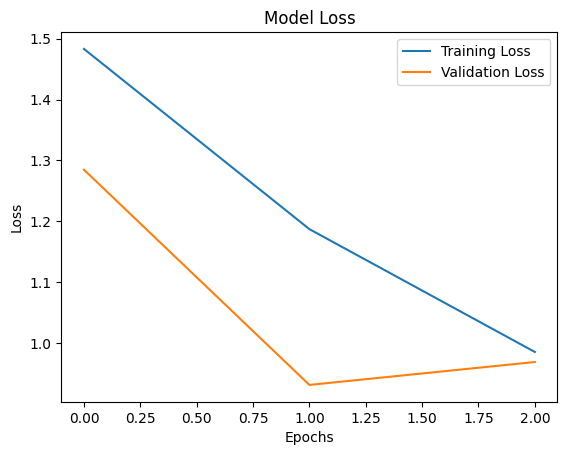

In [28]:
print(History.history.keys())
plt.plot(History.history['loss'], label='Training Loss') 
plt.plot(History.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend() # Needs to be in a list
plt.show()

In [42]:
# list(test_dataset.as_numpy_iterator())

In [43]:
test_dataset = test_dataset.batch(1) # Have to do this because we need to keep into account the dimension of the test dataset as well while evaluating.
lenet_model.evaluate(test_dataset)

# We have a 64.5% accuracy

1377/1377 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9455 - auc: 0.9797 - fn: 39.0000 - fp: 36.0000 - loss: 0.2268 - precision: 0.9476 - recall: 0.9435 - tn: 651.0000 - tp: 651.0000


[0.22675296664237976,
 651.0,
 36.0,
 651.0,
 39.0,
 0.9455337524414062,
 0.9475982785224915,
 0.9434782862663269,
 0.9796668887138367]

# Visualizing Confusion Matrix

In [44]:
labels = []
inp = [] # input

for x,y in test_dataset.as_numpy_iterator():
    labels.append(y[0]) # we did y[0] to ge the number in the list which was like [array([1]), array([0])...]
    inp.append(x)

In [45]:
# labels = np.array([i[0] for i in labels])
# print(labels)
# print(len(labels)) has this kind of a list - '[np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0),'...]

In [46]:
print(np.array(inp).shape)
print(np.array(inp)[:,0,...].shape) # Want to remove the 1st index dimension aka the '1', so we put a '0'. ':' is for selecting the 0th index, '0' is for not selecting the 1st index

(1377, 1, 224, 224, 3)
(1377, 224, 224, 3)


In [47]:
predicted = lenet_model.predict(np.array(inp)[:,0,...])

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


In [48]:
print(predicted.shape)

# We want to make the predicted shape to be the same as the labels shape
print(f'Predicted Shape: {predicted[:,0].shape}')
print(f'Labels Shape: {len(labels)}')

print(predicted[:,0])

(1377, 1)
Predicted Shape: (1377,)
Labels Shape: 1377
[9.0539694e-04 1.1771881e-03 9.7130245e-01 ... 3.4262232e-02 8.2661605e-01
 8.4522784e-01]


[[653  36]
 [ 38 650]]


Text(0.5, 36.72222222222221, 'Predicted')

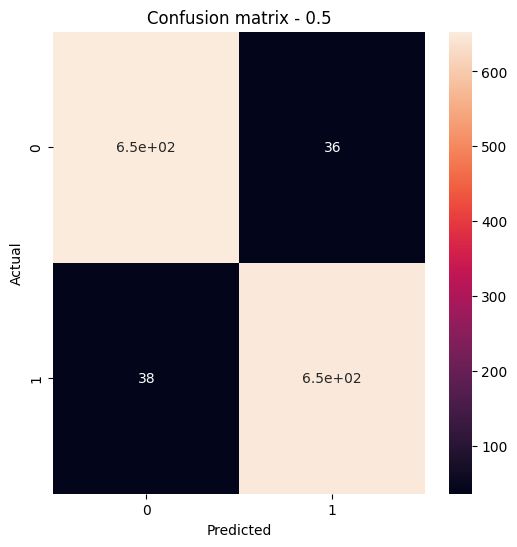

In [49]:
# MAKING THE CONFUSION MATRIX
threshold = 0.5
# If we reduce the threshold to a lower value, then most of our predictions are going to be positive, thereby reducing our false negatives
# Also pick thersholds such that our True Positives and True Negative don't get reduced

cm = confusion_matrix(labels, predicted > threshold) # all values great than threshold is uninfected
print(cm)
plt.figure(figsize=(6,6))

sns.heatmap(cm, annot=True,)
plt.title(f'Confusion matrix - {threshold}')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# tn: 643.0000 - tp: 624.0000
# fn: 65.0000 - fp: 45.0000

We want a low number for the FALSE NEGATIVES(FN), so in this case we want a high 'RECALL'

# ROC Curve

In [ ]:
# We can use this to choose the best threshold.
# A point at the ROC plot is a threshold value for the TP rate and the FP rate.
# Y axis - Recall [TP/(TP + FN)]
# X axis - [FP/(FP+TN)]
# Overall GOAL - FP is MINIMIZED and TP is MAXIMIZED

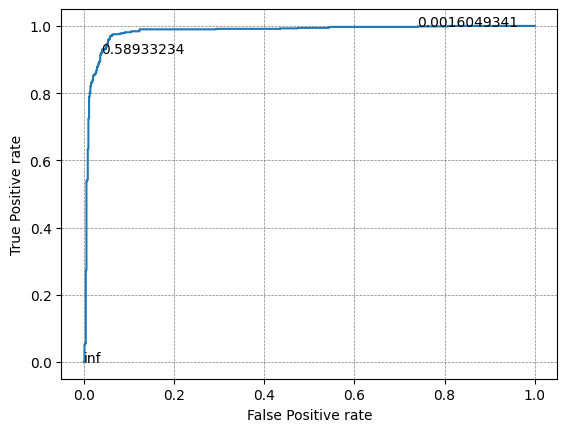

In [50]:
# If we reduce the threshold to a lower value, then most of our predictions are going to be positive, thereby reducing our false negatives
# Also pick thersholds such that our True Positives and True Negative don't get reduced

fp, tp, thresholds = roc_curve(labels, predicted)
plt.plot(fp, tp)
plt.xlabel("False Positive rate")
plt.ylabel("True Positive rate")
plt.grid(color='gray', linestyle='--', linewidth=0.5)

skip =  50 # skip 50 values and then plot it

for i in range(0, len(thresholds), skip):
  plt.text(fp[i], tp[i], thresholds[i]) # to show the thresholds

plt.show()

In [ ]:
def parasite_or_not(x):
    if (x < 0.5):
        return 'P'
    else:
        return 'U'

In [ ]:
parasite_or_not(lenet_model.predict(test_dataset.take(1))[0][0]) 

'''# lenet_model.predict(test_dataset.take(1)) outputs:
[
  [0.85], # Image 0 prediction
  [0.12], # Image 1 prediction
  [0.44], # Image 2 prediction
  ...
  [0.91]  # Image 32 prediction
]
TensorFlow models output predictions in a 2D batch format [[0.85], [0.12]]. The first [0] selects the specific image in the batch, and the second [0] extracts the raw probability number 
from inside that vector.'''

NameError: name 'lenet_model' is not defined

In [ ]:
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_model.predict(image)[0][0])))
    plt.axis('off')

NameError: name 'test_dataset' is not defined

# Saving to and Loading from Google Drive

In [ ]:
from google.colab import drive # type: ignore
drive.mount('/content/drive')

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-t4-s-kkb-usw4b2-371r393nplxzb?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_lo

In [ ]:
lenet_model.export('/content/drive/MyDrive/lenet_saved_directory')
drive_folder_path = '/content/drive/MyDrive/lenet_saved_directory'

# Load the directory as a specialized inference layer
lenet_loaded = tf.keras.layers.TFSMLayer(drive_folder_path, call_endpoint='serve')

print("Model loaded successfully from Google Drive!")

In [ ]:
lenet_model.save('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded = tf.keras.models.load_model('/content/drive/MyDrive/lenet_malaria_saved_model.keras')
lenet_loaded.summary()

In [ ]:
# Using the LOADED MODEL from google drive to do the predictions
for i,(image,label) in enumerate(test_dataset.take(9)):

    ax = plt.subplot(3,3, i+1)
    plt.imshow(image[0])
    plt.title(str(parasite_or_not(label.numpy()[0])) + ':' + str(parasite_or_not(lenet_loaded.predict(image)[0][0])))
    plt.axis('off')

In [ ]:
lenet_loaded.evaluate(test_dataset)

## Saving using the HDF5 method -> lightweight Model Saving Method

In [ ]:
# In a HDF5 format the configurations aren't stored, so you will have to compile the model again
lenet_model.save('/content/drive/MyDrive/lenet_malaria_model.h5')


In [ ]:
h5_model_path = '/content/drive/MyDrive/lenet_malaria_model.h5'
lenet_loaded_h5 = tf.keras.models.load_model(h5_model_path, compile=False) 
# If you only want to use the model for inference (making predictions) 
#and want to skip loading the optimizer, you can add compile=False to speed things up
# Setting compile=False tells Keras: "Just load the brain (weights and architecture). Do not waste time loading the training setup or rebuilding the optimizer."
lenet_loaded_h5.summary()

In [ ]:
# lenet_loaded_h5.evaluate(test_dataset) # In a HDF5 format the configurations aren't stored, so you will have to compile the model again

# ERROR GIVEN - You must call `compile()` before using the model.

## Saving Just the Weights given that we already have the model's configurations

In [ ]:
# lenet_model.save_weights("weights/lenet_weights.weights.h5")

In [ ]:
# lenet_weights_model = lenet_model.load_weights("weights/lenet_weights")